In [3]:
import pandas as pd
from io import StringIO

data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""

df = pd.read_csv(StringIO(data))
df.to_csv("students.csv", index=False)

print("student.csv created using pandas.")

student.csv created using pandas.


In [18]:
#Task 1 — Data Exploration with Pandas
df= pd.read_csv("students.csv")
print(df.head(5))
print(f"shape of the dataframe={df.shape}")
print(df.dtypes)
print(df.describe())

print(f"students who {df['passed'].value_counts()}")
subject_cols = ['math', 'science', 'english', 'history', 'pe']

passed_avg = df[df['passed'] == 1][subject_cols].mean()
failed_avg = df[df['passed'] == 0][subject_cols].mean()
print(f"passed students average: {passed_avg}")
print(f"failed students average: {failed_avg}")
df['average_score'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['average_score'].idxmax()]
print(top_student[['name', 'average_score']])

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  
shape of the dataframe=(15, 9)
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object
            math    science    english    history         pe  attendance_pc

Bar Graph


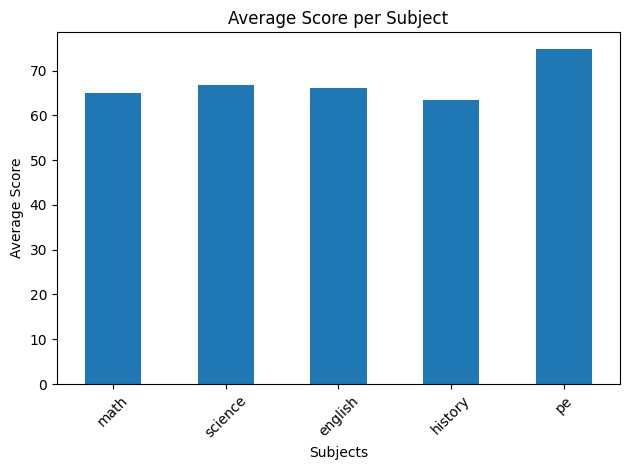

histogram


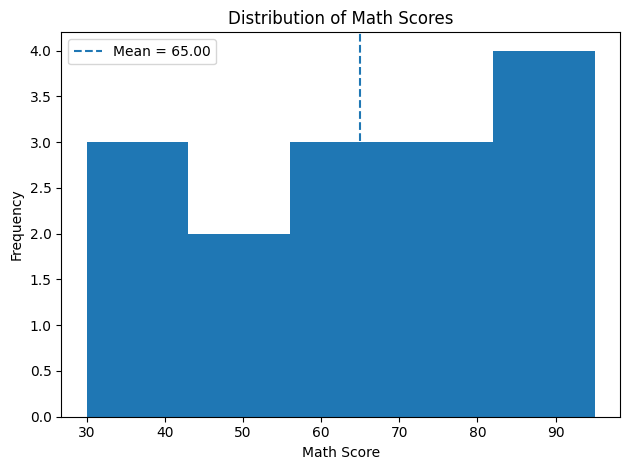

scatter plot


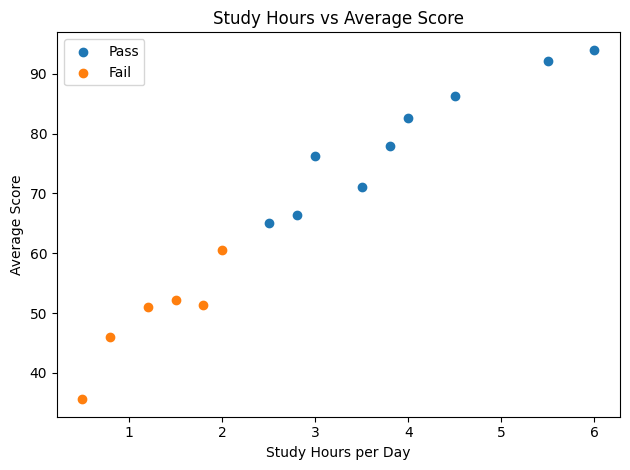

Box plot


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20352\3968345467.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


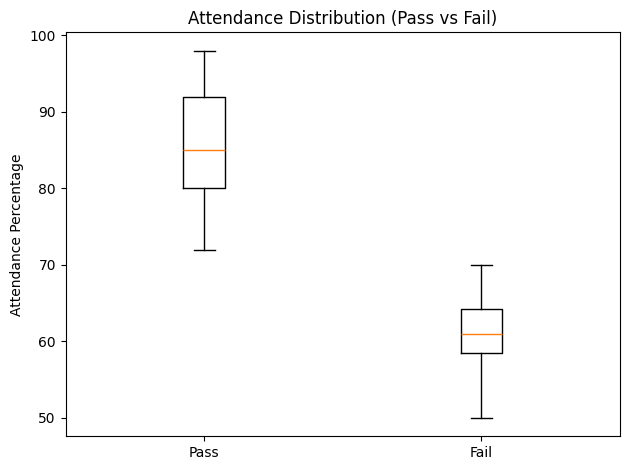

line plot


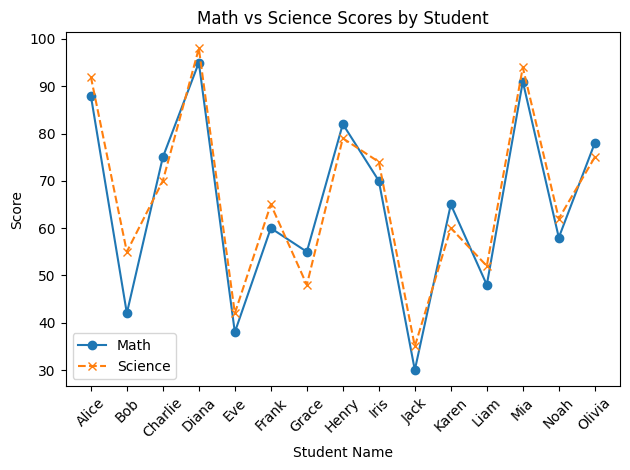

In [19]:
#Task 2 — Data Visualization with Matplotlib
import matplotlib.pyplot as plt
#1. Bar Chart
print("Bar Graph")
avg_scores = df[subject_cols].mean()

plt.figure()
avg_scores.plot(kind='bar')
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot1_bar.png")
plt.show()
#2. Histogram
print("histogram")
plt.figure()
plt.hist(df['math'], bins=5)
mean_math = df['math'].mean()

plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_hist.png")
plt.show()
#3. Scatter Plot
print("scatter plot")
plt.figure()
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)
pass_data = df[df['passed'] == 1]
fail_data = df[df['passed'] == 0]

plt.scatter(pass_data['study_hours_per_day'], pass_data['avg_score'], label="Pass")
plt.scatter(fail_data['study_hours_per_day'], fail_data['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot3_scatter.png")
plt.show()

#Box Plot
print("Box plot")
pass_attendance = pass_data['attendance_pct'].tolist()
fail_attendance = fail_data['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution (Pass vs Fail)")
plt.ylabel("Attendance Percentage")
plt.tight_layout()
plt.savefig("plot4_box.png")
plt.show()

# 5. Line Plot 
print("line plot")
plt.figure()

plt.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math')
plt.plot(df['name'], df['science'], marker='x', linestyle='--', label='Science')

plt.title("Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()

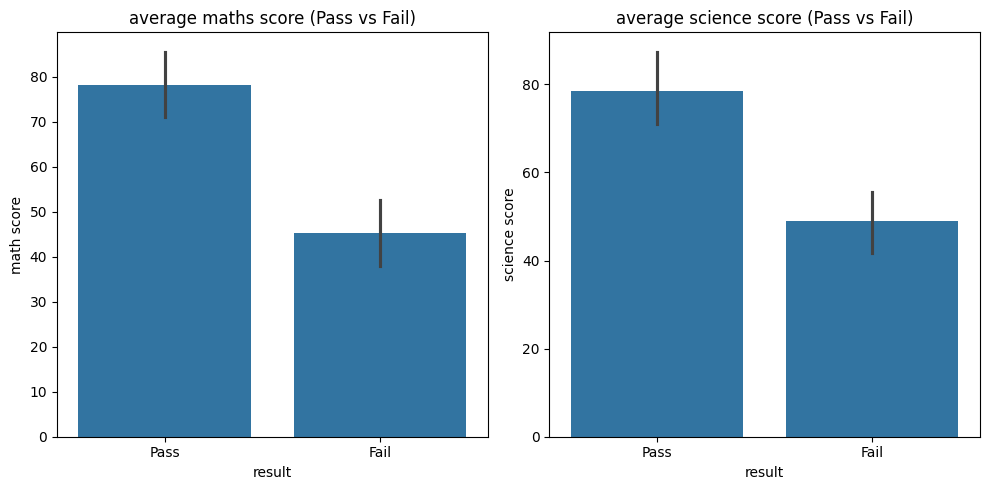

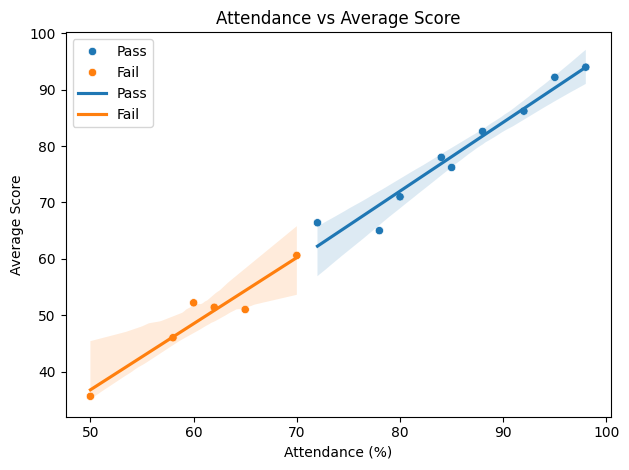

In [20]:
import seaborn as sns
df = pd.read_csv("students.csv")

# Created avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# Converted passed (0/1) to labels for better visualization
df['passed_label'] = df['passed'].map({1: 'Pass', 0: 'Fail'})

# 1. Bar Plot (Math & Science)
plt.figure(figsize=(10, 5))

# Subplot 1: Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed_label', y='math', ax=ax1)
ax1.set_title("average maths score (Pass vs Fail)")
ax1.set_xlabel("result")
ax1.set_ylabel("math score")

# Subplot 2: Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed_label', y='science', ax=ax2)
ax2.set_title("average science score (Pass vs Fail)")
ax2.set_xlabel("result")
ax2.set_ylabel("science score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()


# =============================
# 2. Scatter + Regression Plot
# =============================
plt.figure()

# Scatter plot with hue
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed_label')

# Regression lines
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()


# 3. Comments (Comparison)
#Seaborn simplifies the process of creating attractive and meaningful visualizations, requiring less code than Matplotlib.
#Its features, such as automatic grouping using hue and built-in statistical visualizations like regression lines, make it very user-friendly. 
#On the other hand, Matplotlib offers greater flexibility and control when it comes to detailed customization.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# Step 1 — Preparing Data
df = pd.read_csv("students.csv")

feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]
y = df['passed']

# Training-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Step 2 — Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training accuracy
train_preds = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_preds)
print("Training Accuracy:", train_acc)



# Step 3 — Evaluating Model

y_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_acc)

print("Test Predictions:")

# Get names using index
names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    result = "correct" if actual == pred else "wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {result}")



# Step 4 — Feature Importance
coefficients = model.coef_[0]

feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (sorted):\n")
for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")


# Plot
features = [f[0] for f in feature_importance]
coefs = [f[1] for f in feature_importance]

colors = ['green' if c > 0 else 'red' for c in coefs]

plt.figure()
plt.barh(features, coefs, color=colors)
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Feature Importance (Logistic Regression)")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()


# =============================
# Step 5 — Predict New Student
# =============================
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)[0]
probability = model.predict_proba(new_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("\nNew Student Prediction:")
print("Prediction:", result)
print(f"Probability (Fail, Pass): {probability}")